In [ ]:
# %pip install -U transformers
# %pip install -U datasets
# %pip install -U peft
# %pip install -U accelerate
# %pip install -U bitsandbytes
# %pip install -U trl


In [ ]:
from datasets import load_dataset

# ds = load_dataset("AI-MO/NuminaMath-CoT")
ds = load_dataset("5CD-AI/Vietnamese-395k-meta-math-MetaMathQA-gg-translated")


In [ ]:
train_test_split_ds = ds["train"].train_test_split(test_size=0.3, seed=42, shuffle=True)
train_ds = train_test_split_ds["train"]
eval_ds = train_test_split_ds["test"]


In [ ]:
train_ds = train_ds.to_pandas()
eval_ds = eval_ds.to_pandas()


In [ ]:
train_ds.head()


,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi
0,"If Ken received $1750, then Tony received 2 * ...",Mr. Sam shared a certain amount of money betwe...,GSM_Rephrased,If Ken received $1750 and Tony received twice ...,Ông Sam chia một số tiền nhất định cho hai con...,Nếu Ken nhận được 1750 đô la và Tony nhận được...,Nếu Ken nhận được 1750$ thì Tony nhận được 2 *...
1,Using the property $\log_a b + \log_a c = \log...,Find $\log_{10} 40 +\log_{10} 25$.,MATH_AnsAug,Find $\log_{10} 40 +\log_{10} 25$.,Tìm $\log_{10} 40 +\log_{10} 25$.,Tìm $\log_{10} 40 +\log_{10} 25$.,Sử dụng thuộc tính $\log_a b + \log_a c = \log...
2,We can rewrite the equation $y = |x-a| + |x-b|...,"Positive integers $a$, $b$, and $c$ are chosen...",MATH_Rephrased,"Given that $a$, $b$, and $c$ are positive inte...","Các số nguyên dương $a$, $b$, và $c$ được chọn...","Cho rằng $a$, $b$ và $c$ là các số nguyên dươn...",Chúng ta có thể viết lại phương trình $y = |xa...
3,"To find the factors of 30, we can list out all...",How many positive factors does 30 have?,MATH_AnsAug,How many positive factors does 30 have?,30 có bao nhiêu ước số dương?,30 có bao nhiêu ước số dương?,"Để tìm các thừa số của 30, chúng ta có thể liệ..."
4,The area of the square region is equal to the ...,What is the smallest possible number of whole ...,MATH_AnsAug,What is the smallest possible number of whole ...,Cần bao nhiêu số nhỏ nhất có thể của toàn bộ h...,Cần bao nhiêu số nhỏ nhất có thể của toàn bộ h...,Diện tích của khu vực hình vuông bằng tổng diệ...


In [ ]:
eval_ds.head()


,response_en,original_question_en,type,query_en,original_question_vi,query_vi,response_vi
0,"If half of the students wore lipstick, then th...","On national lipstick day, half of the students...",GSM_AnsAug,"On national lipstick day, half of the students...","Vào ngày son môi quốc gia, một nửa số học sinh...","Vào ngày son môi quốc gia, một nửa số học sinh...",Nếu một nửa số học sinh tô son thì có 200/2 = ...
1,We know that the width of the rectangle is 4 i...,There is a rectangle that is 4 inches wide. If...,GSM_AnsAug,There is a rectangle that is 4 inches wide. If...,Có một hình chữ nhật có chiều rộng 4 inch. Nếu...,Có một hình chữ nhật có chiều rộng 4 inch. Nếu...,Chúng ta biết chiều rộng của hình chữ nhật là ...
2,We want to find the value of $X$ in the given ...,Find $1273 + 120 \div 60 - 173$.,MATH_FOBAR,Find $1273 + 120 \div 60 - X$.\nIf we know the...,Tìm $1273 + 120 \div 60 - 173$.,Tìm $1273 + 120 \div 60 - X$. Nếu chúng ta biế...,Chúng ta muốn tìm giá trị của $X$ trong biểu t...
3,"If three fourths of the jelly beans are red, t...","There are 4,000 jelly beans in a jar. If three...",GSM_AnsAug,"There are 4,000 jelly beans in a jar. If three...",Có 4.000 hạt thạch trong một cái lọ. Nếu 3/4 s...,Có 4.000 hạt thạch trong một cái lọ. Nếu 3/4 s...,Nếu 3/4 số hạt thạch có màu đỏ thì có 3/4 * 40...
4,Since $\cos \frac{\pi}{6} = \frac{\sqrt{3}}{2}...,Compute $\arccos \frac{\sqrt{3}}{2}.$ Express...,MATH_AnsAug,Compute $\arccos \frac{\sqrt{3}}{2}.$ Express...,Tính $\arccos \frac{\sqrt{3}}{2}.$ Thể hiện câ...,Tính $\arccos \frac{\sqrt{3}}{2}.$ Thể hiện câ...,"Vì $\cos \frac{\pi}{6} = \frac{\sqrt{3}}{2}$, ..."


In [ ]:
train_ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276500 entries, 0 to 276499
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   response_en           276500 non-null  object
 1   original_question_en  276500 non-null  object
 2   type                  276500 non-null  object
 3   query_en              276500 non-null  object
 4   original_question_vi  276500 non-null  object
 5   query_vi              276500 non-null  object
 6   response_vi           276500 non-null  object
dtypes: object(7)
memory usage: 14.8+ MB


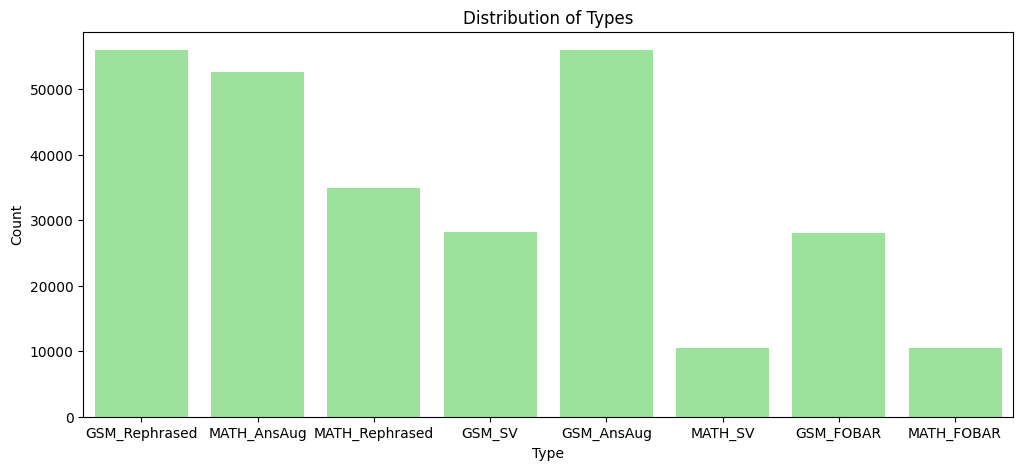

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.countplot(x="type", data=train_ds, color="lightgreen")
plt.title("Distribution of Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


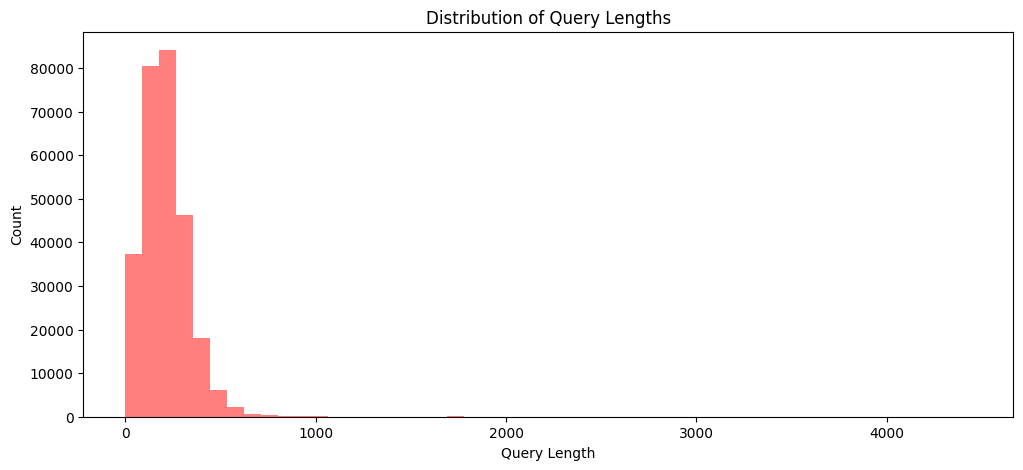

In [ ]:
vi_queries = train_ds["query_vi"]
query_lens = [len(query) for query in vi_queries]

plt.figure(figsize=(12, 5))
plt.hist(query_lens, bins=50, color="red", alpha=0.5)
plt.title("Distribution of Query Lengths")
plt.xlabel("Query Length")
plt.ylabel("Count")
plt.show()


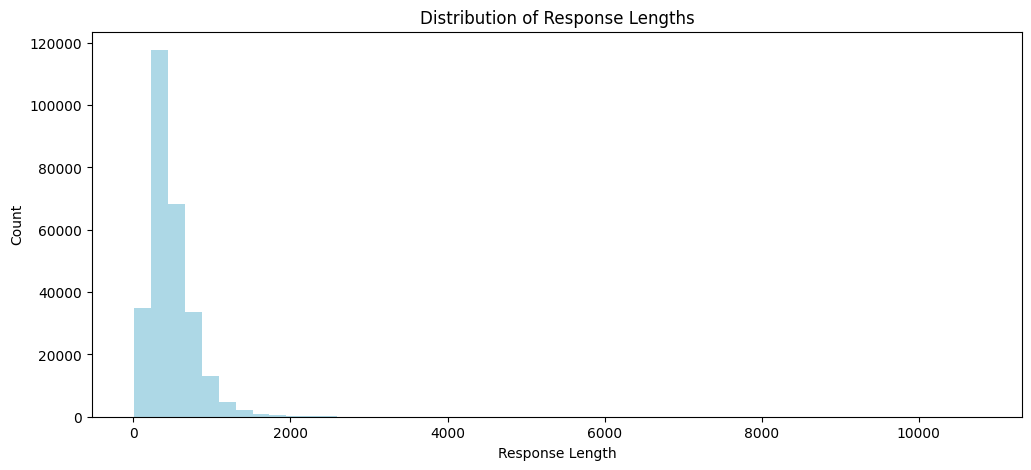

In [ ]:
response_queries = train_ds["response_vi"]
response_lens = [len(query) for query in response_queries]

plt.figure(figsize=(12, 5))
plt.hist(response_lens, bins=50, color="lightblue")
plt.title("Distribution of Response Lengths")
plt.xlabel("Response Length")
plt.ylabel("Count")
plt.show()


## Preprocessing

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B-Instruct")
if tokenizer.pad_token is None:
    tokenizer.pad_token = (
        tokenizer.eos_token
    )  # Rất quan trọng => Các mô hình Causal LM thường không có pad_token mặc định, nên chúng ta gán nó bằng eos_token (End-of-Sequence token).


In [ ]:
from datasets import Dataset
import pandas as pd


def prepare_data(ds, tokenizer, max_length=512, batch_size=1000):
    """Process dataset efficiently using map"""

    # If input is a DataFrame, convert to Hugging Face Dataset
    if isinstance(ds, pd.DataFrame):
        ds = Dataset.from_pandas(ds)

    def format_and_tokenize(examples):
        formatted_texts = []
        for query, response in zip(examples["query_vi"], examples["response_vi"]):
            messages = [
                {
                    "role": "system",
                    "content": "Please reason step by step, and put your final answer.",
                },
                {"role": "user", "content": query},
                {"role": "assistant", "content": response},
            ]
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=False
            )
            formatted_texts.append(text)

        # Tokenize
        tokenized = tokenizer(
            formatted_texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

        # For causal LM, labels = input_ids
        tokenized["labels"] = tokenized["input_ids"]
        return tokenized

    # Use Hugging Face Dataset.map()
    processed_dataset = ds.map(
        format_and_tokenize,
        batched=True,
        batch_size=batch_size,
        remove_columns=ds.column_names,
        desc="Tokenizing dataset",
    )

    return processed_dataset


In [ ]:
eval_ds = prepare_data(eval_ds, tokenizer)


Tokenizing dataset:   0%|          | 0/118500 [00:00<?, ? examples/s]

In [ ]:
train_ds = prepare_data(train_ds, tokenizer)


Tokenizing dataset:   0%|          | 0/276500 [00:00<?, ? examples/s]

# Load model with 4-bit

In [1]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TapexTokenizer,
)
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-Math-1.5B-Instruct",
    dtype=torch.float16,
    device_map="auto",  # Auto assign model to VRAM/RAM
)


Some parameters are on the meta device because they were offloaded to the cpu.


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TapexTokenizer,
)
import torch

model_name = "Qwen/Qwen2.5-Math-1.5B-Instruct"
device = "cuda" if torch.cuda.is_available() else "cpu"

# QLora Config for 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,  # Use QLora 4-bit config
    device_map="auto",  # Auto assign model to VRAM/RAM
)

# Do not use cache with gradient checkpointing
model.config.use_cache = False
model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": True}
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # for CausalLM


# PEFT (LoRA) configuration

In [ ]:
import torch

print("--- TEST THỬ MODEL GỐC (CHƯA FINE-TUNE) ---")

# --- Thay đổi câu hỏi test của bạn ở đây ---
test_query = "Một hình chữ nhật có chiều dài 10cm và chiều rộng 5cm. Tính chu vi của hình chữ nhật đó."
# test_query = "Giải phương trình bậc hai: x^2 - 3x + 2 = 0"

messages = [
    {
        "role": "system",
        "content": "Please reason step by step, and put your final answer.",
    },
    {"role": "user", "content": test_query},
]

# Áp dụng template, LƯU Ý: add_generation_prompt=True
# (True vì đây là lúc test, chúng ta muốn model sinh ra câu trả lời)
prompt = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)

print(f"[PROMPT GỬI ĐẾN MODEL]:\n{prompt}\n")

# Tokenize và đưa lên GPU
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Chạy model.generate
# model.generate() hoạt động bình thường với model 4-bit
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,  # Độ dài tối đa cho câu trả lời
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        do_sample=True,
        temperature=0.6,
        top_p=0.9,
    )

# Decode phần trả lời (bỏ qua phần prompt)
response_ids = outputs[0][inputs.input_ids.shape[1] :]
response_text = tokenizer.decode(response_ids, skip_special_tokens=True)

print(f"--- [CÂU TRẢ LỜI CỦA MODEL GỐC] ---\n{response_text}")


--- TEST THỬ MODEL GỐC (CHƯA FINE-TUNE) ---
[PROMPT GỬI ĐẾN MODEL]:
<|im_start|>system
Please reason step by step, and put your final answer.<|im_end|>
<|im_start|>user
Một hình chữ nhật có chiều dài 10cm và chiều rộng 5cm. Tính chu vi của hình chữ nhật đó.<|im_end|>
<|im_start|>assistant


--- [CÂU TRẢ LỜI CỦA MODEL GỐC] ---
To determine the perimeter of a rectangle, we use the formula:

\[ P = 2 \times (\text{length} + \text{width}) \]

Given the length is 10 cm and the width is 5 cm, we substitute these values into the formula:

\[ P = 2 \times (10 + 5) \]
\[ P = 2 \times 15 \]
\[ P = 30 \]

Therefore, the perimeter of the rectangle is \(\boxed{30}\) cm.


In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# Get prepare model for k-bit training
model = prepare_model_for_kbit_training(model)


In [ ]:
# Set up LoRA configurations (PEFT)
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "up_proj",
        "down_proj",
        "gate_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# Apply PEFT to the model
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


# Config

In [ ]:
class Config:
    # Training settings
    OUTPUT_DIR = "./result_qwen2.5-1.5b-math-finetuned"
    LOGGING_DIR = "./logs"
    EPOCHS = 1
    BATCH_SIZE = 8
    PER_DEVICE_EVAL_BATCH_SIZE = 12
    GRADIENT_ACCUMULATION_STEPS = 8
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 0.05
    MAX_GRAD_NORM = 0.4
    WARMUP_RATIO = 0.03
    MAX_STEPS = -1

    # Evaluation and saving
    SAVE_STRATEGY = "steps"
    EVAL_STRATEGY = "steps"
    EVAL_STEPS = 1000
    SAVE_STEPS = 1000
    SAVE_TOTAL_LIMIT = 2
    LOGGING_STEPS = 10

    # Mixed precision
    FP16 = False
    BF16 = True

    # Other settings
    GROUP_BY_LENGTH = True
    LR_SCHEDULER_TYPE = "constant_with_warmup"
    REPORT_TO = "tensorboard"
    LOAD_BEST_MODEL_AT_END = True
    METRIC_FOR_BEST_MODEL = "eval_loss"
    GREATER_IS_BETTER = False
    EVAL_ACCUMULATION_STEPS = 1


cfg = Config()


# TrainingArgument and Trainer

In [ ]:
from transformers import (
    TrainingArguments,
    Trainer,
    TrainerCallback,
    DataCollatorForLanguageModeling,
)


data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
training_args = TrainingArguments(
    output_dir=cfg.OUTPUT_DIR,
    num_train_epochs=cfg.EPOCHS,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=cfg.GRADIENT_ACCUMULATION_STEPS,
    save_strategy=cfg.SAVE_STRATEGY,
    eval_strategy=cfg.EVAL_STRATEGY,
    eval_steps=cfg.EVAL_STEPS,
    save_steps=cfg.SAVE_STEPS,
    save_total_limit=cfg.SAVE_TOTAL_LIMIT,
    logging_steps=cfg.LOGGING_STEPS,
    learning_rate=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
    fp16=cfg.FP16,
    bf16=cfg.BF16,
    max_grad_norm=cfg.MAX_GRAD_NORM,
    max_steps=cfg.MAX_STEPS,
    warmup_ratio=cfg.WARMUP_RATIO,
    group_by_length=cfg.GROUP_BY_LENGTH,
    lr_scheduler_type=cfg.LR_SCHEDULER_TYPE,
    report_to=cfg.REPORT_TO,
    logging_dir=cfg.LOGGING_DIR,
    load_best_model_at_end=cfg.LOAD_BEST_MODEL_AT_END,
    metric_for_best_model=cfg.METRIC_FOR_BEST_MODEL,
    greater_is_better=cfg.GREATER_IS_BETTER,
    eval_accumulation_steps=cfg.EVAL_ACCUMULATION_STEPS,
    remove_unused_columns=False,
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
)


: 

# Train model

In [ ]:
trainer.train()


/home/guest/.conda/envs/CS431/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
1000,0.842600,0.833538
2000,0.671400,0.666380
3000,0.560600,0.566544
4000,0.503300,0.501346


/home/guest/.conda/envs/CS431/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/guest/.conda/envs/CS431/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return 

# Save model

In [ ]:
trainer.save_model(cfg.OUTPUT_DIR)
